# Website Performance Data Analysis

# Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load file

In [8]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\data-export (1) (1).csv")

In [12]:
df

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
...,...,...,...,...,...,...,...,...,...,...
3178,Unassigned,2024042806,0,1,0,0,0,2,0,2
3179,Unassigned,2024043005,0,1,0,0,0,2,0,2
3180,Unassigned,2024043006,0,1,0,0,0,2,0,2
3181,Unassigned,2024050105,0,1,0,0,0,2,0,2


# Data Exploration, Handling, Cleaning and Transformation

In [23]:
df.columns = df.iloc[0]
df = df.drop(index = 0).reset_index(drop = True)
df.columns = ["Channel_Group","Date_Hour","Users","Sessions","Engaged_Sessions","Avg_Engagement_Time_Per_Session","Engaged_Sessions_Per_User","Events_Per_Session","Engagement_Rate","Event_Count"]


In [25]:
df.head()

,Channel_Group,Date_Hour,Users,Sessions,Engaged_Sessions,Avg_Engagement_Time_Per_Session,Engaged_Sessions_Per_User,Events_Per_Session,Engagement_Rate,Event_Count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Channel_Group                    3182 non-null   object
 1   Date_Hour                        3182 non-null   object
 2   Users                            3182 non-null   object
 3   Sessions                         3182 non-null   object
 4   Engaged_Sessions                 3182 non-null   object
 5   Avg_Engagement_Time_Per_Session  3182 non-null   object
 6   Engaged_Sessions_Per_User        3182 non-null   object
 7   Events_Per_Session               3182 non-null   object
 8   Engagement_Rate                  3182 non-null   object
 9   Event_Count                      3182 non-null   object
dtypes: object(10)
memory usage: 248.7+ KB


In [34]:
df["Date_Hour"] = pd.to_datetime(df["Date_Hour"], format = "%Y%m%d%H", errors = "coerce")


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Channel_Group                    3182 non-null   object        
 1   Date_Hour                        3182 non-null   datetime64[ns]
 2   Users                            3182 non-null   object        
 3   Sessions                         3182 non-null   object        
 4   Engaged_Sessions                 3182 non-null   object        
 5   Avg_Engagement_Time_Per_Session  3182 non-null   object        
 6   Engaged_Sessions_Per_User        3182 non-null   object        
 7   Events_Per_Session               3182 non-null   object        
 8   Engagement_Rate                  3182 non-null   object        
 9   Event_Count                      3182 non-null   object        
dtypes: datetime64[ns](1), object(9)
memory usage: 248.7+ KB


In [40]:
df.head()

,Channel_Group,Date_Hour,Users,Sessions,Engaged_Sessions,Avg_Engagement_Time_Per_Session,Engaged_Sessions_Per_User,Events_Per_Session,Engagement_Rate,Event_Count
0,Direct,2024-04-16 23:00:00,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024-04-17 23:00:00,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [44]:
num_col = df.columns.drop(["Channel_Group","Date_Hour"])
df[num_col] = df[num_col].apply(pd.to_numeric, errors = "coerce")

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Channel_Group                    3182 non-null   object        
 1   Date_Hour                        3182 non-null   datetime64[ns]
 2   Users                            3182 non-null   int64         
 3   Sessions                         3182 non-null   int64         
 4   Engaged_Sessions                 3182 non-null   int64         
 5   Avg_Engagement_Time_Per_Session  3182 non-null   float64       
 6   Engaged_Sessions_Per_User        3182 non-null   float64       
 7   Events_Per_Session               3182 non-null   float64       
 8   Engagement_Rate                  3182 non-null   float64       
 9   Event_Count                      3182 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(4), object(1)
memory

In [48]:
df["Hour"] = df["Date_Hour"].dt.hour

In [50]:
df.head()

,Channel_Group,Date_Hour,Users,Sessions,Engaged_Sessions,Avg_Engagement_Time_Per_Session,Engaged_Sessions_Per_User,Events_Per_Session,Engagement_Rate,Event_Count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Channel_Group                    3182 non-null   object        
 1   Date_Hour                        3182 non-null   datetime64[ns]
 2   Users                            3182 non-null   int64         
 3   Sessions                         3182 non-null   int64         
 4   Engaged_Sessions                 3182 non-null   int64         
 5   Avg_Engagement_Time_Per_Session  3182 non-null   float64       
 6   Engaged_Sessions_Per_User        3182 non-null   float64       
 7   Events_Per_Session               3182 non-null   float64       
 8   Engagement_Rate                  3182 non-null   float64       
 9   Event_Count                      3182 non-null   int64         
 10  Hour                             3182 non-null   int32      

In [54]:
df.isnull().sum()

Channel_Group                      0
Date_Hour                          0
Users                              0
Sessions                           0
Engaged_Sessions                   0
Avg_Engagement_Time_Per_Session    0
Engaged_Sessions_Per_User          0
Events_Per_Session                 0
Engagement_Rate                    0
Event_Count                        0
Hour                               0
dtype: int64

In [56]:
df.describe()

,Date_Hour,Users,Sessions,Engaged_Sessions,Avg_Engagement_Time_Per_Session,Engaged_Sessions_Per_User,Events_Per_Session,Engagement_Rate,Event_Count,Hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441216,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


# Data Analysis and Data Visualization

## _Pattern Or Trend Observation In Website Sessions And Users Over Time._

In [62]:
sns.set(style = "whitegrid")

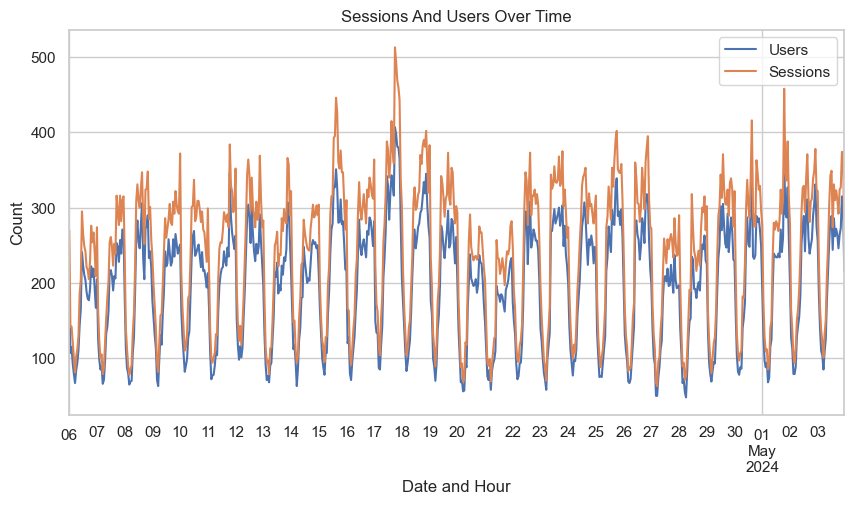

In [191]:
plt.figure(figsize = (10,5))
df.groupby("Date_Hour")[["Users","Sessions"]].sum().plot(ax=plt.gca())
plt.title("Sessions And Users Over Time")
plt.xlabel("Date and Hour")
plt.ylabel("Count")
plt.show()

## _Most Users By Channel_

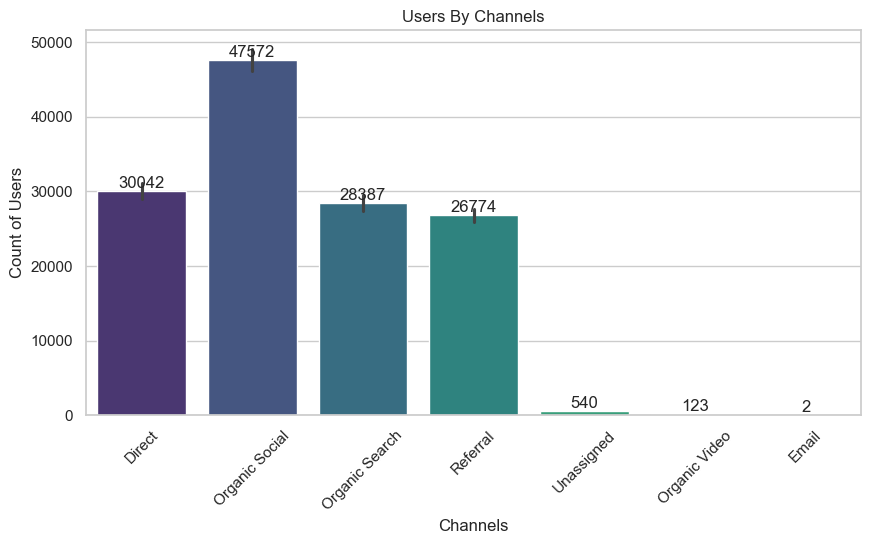

In [189]:
plt.figure(figsize = (10,5))
ax = sns.barplot(data= df, x = "Channel_Group", y = "Users", hue = "Channel_Group", estimator = np.sum, palette = "viridis")
for i in ax.containers:
    ax.bar_label(i)
plt.title("Users By Channels")
plt.xticks(rotation=45)
plt.xlabel("Channels")
plt.ylabel("Count of Users")
plt.show()

## _Highest And Average Engagement Time Of Users By Channels_.

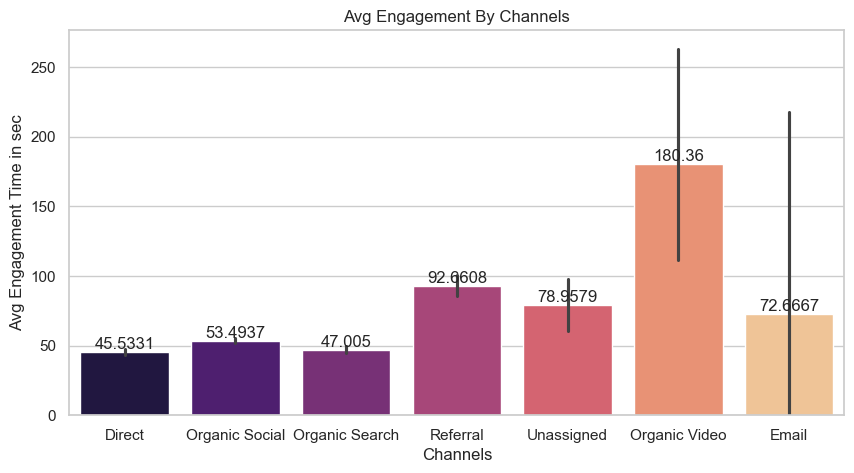

In [187]:
plt.figure(figsize = (10,5))
ac = sns.barplot(data = df, x = "Channel_Group", y = "Avg_Engagement_Time_Per_Session", hue = "Channel_Group", estimator = np.mean, palette = "magma")
for i in ac.containers:
    ac.bar_label(i)
plt.title("Avg Engagement By Channels")
plt.xlabel("Channels")
plt.ylabel("Avg Engagement Time in sec")
plt.show()

## _Engagement Rate Distribution By Different Traffic Channels_

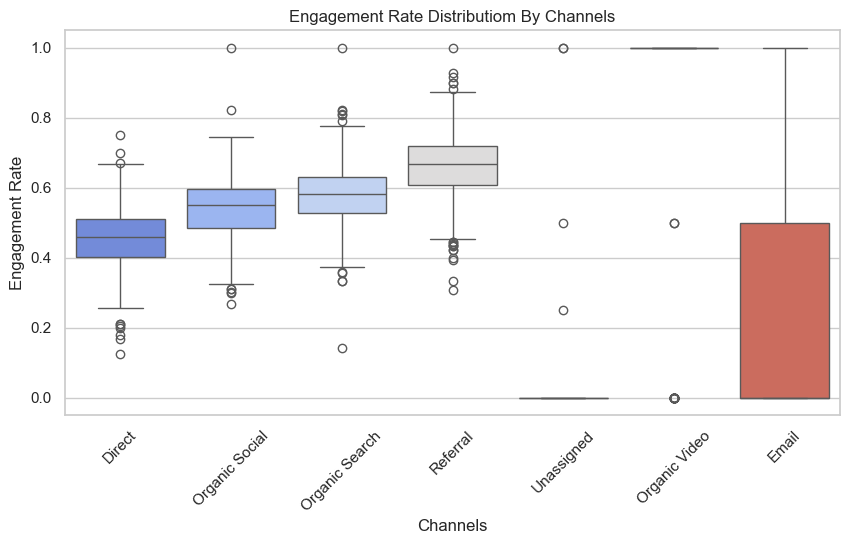

In [185]:
plt.figure(figsize=(10,5))
sns.boxplot(data = df, x =  "Channel_Group", y = "Engagement_Rate", hue = "Channel_Group", palette = "coolwarm")
plt.title("Engagement Rate Distributiom By Channels")
plt.xlabel("Channels")
plt.ylabel("Engagement Rate")
plt.xticks(rotation=45)
plt.show()

## _Engaged VS Non Engaged Sessions_.

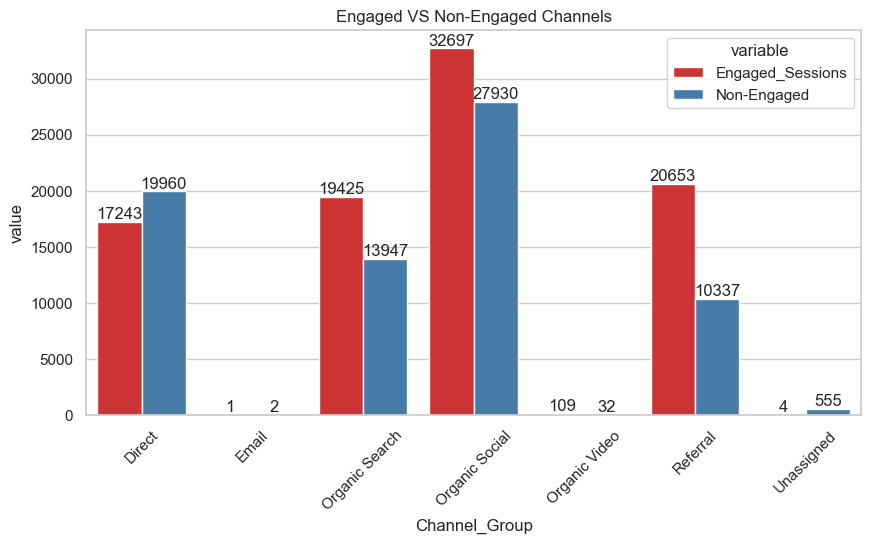

In [166]:
session_df = df.groupby("Channel_Group")[["Sessions", "Engaged_Sessions"]].sum().reset_index()
session_df["Non-Engaged"] = session_df["Sessions"] - session_df["Engaged_Sessions"]
session_df_melted = session_df.melt(id_vars = "Channel_Group", value_vars = ["Engaged_Sessions", "Non-Engaged"])

plt.figure(figsize = (10,5))
en = sns.barplot(data = session_df_melted, x = "Channel_Group", y = "value", hue = "variable", palette = "Set1")
for i in en.containers:
    en.bar_label(i)
plt.title("Engaged VS Non-Engaged Channels")
plt.xticks(rotation=45)
plt.show()

## _Most Channel Traffic By Hours._

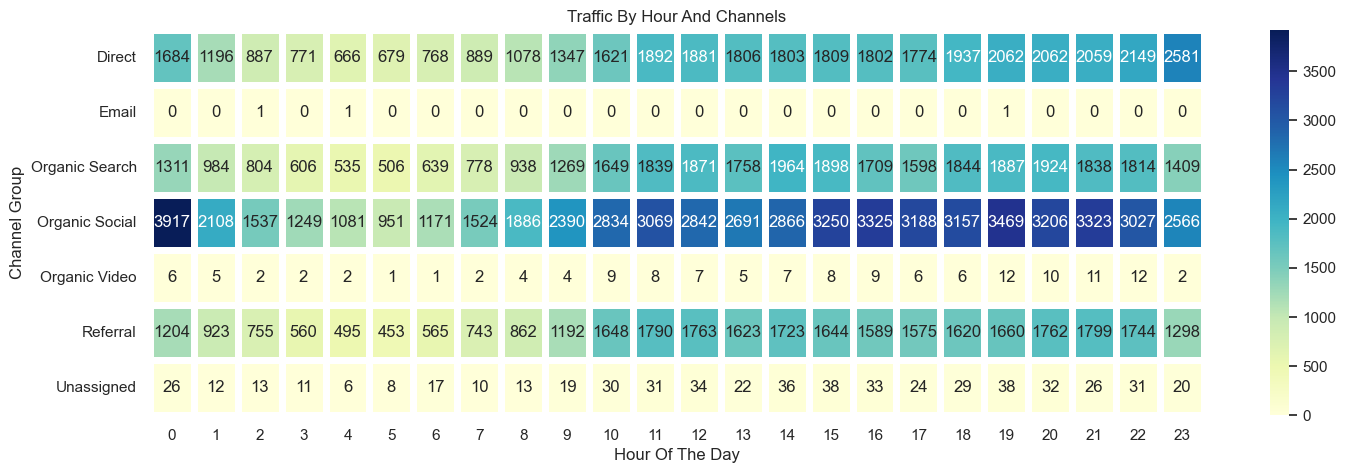

In [193]:
heat_map = df.groupby(["Channel_Group", "Hour"]) ["Sessions"].sum().unstack().fillna(0)
plt.figure(figsize=(17,5))
sns.heatmap(heat_map, cmap = "YlGnBu", linewidths = 5, annot = True, fmt = '.0f' )
plt.title("Traffic By Hour And Channels")
plt.xlabel("Hour Of The Day")
plt.ylabel("Channel Group")
plt.show()

## Engagement Rate VS Engagement Sessions Over Time

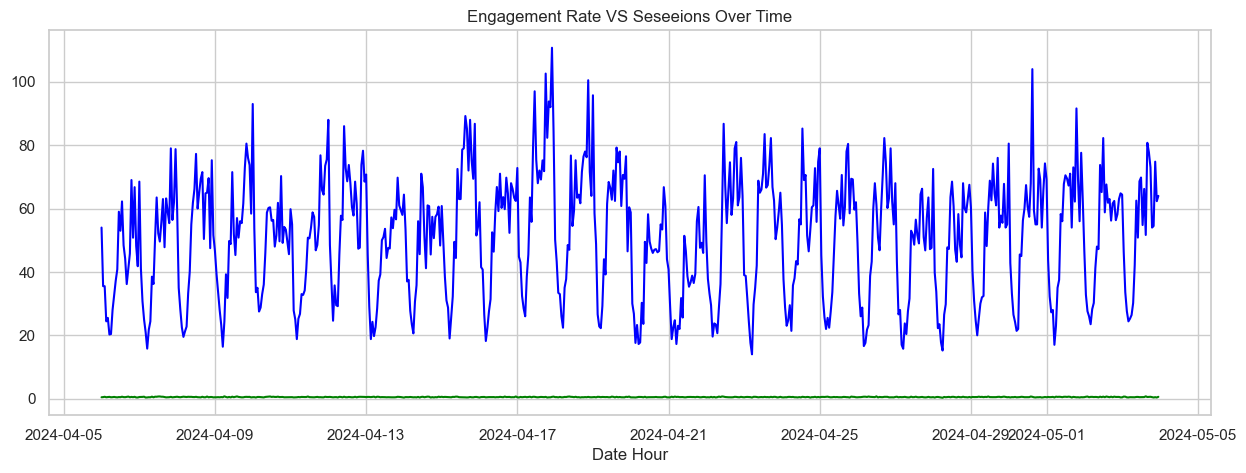

In [208]:
df_plot = df.groupby("Date_Hour")[["Engagement_Rate", "Sessions"]].mean().reset_index()
plt.figure(figsize = (15,5))
plt.plot(df_plot["Date_Hour"], df_plot["Engagement_Rate"], label = "Engagement_Rate", color = "green")
plt.plot(df_plot["Date_Hour"], df_plot["Sessions"], label = "Sessions", color = "blue")
plt.title("Engagement Rate VS Seseeions Over Time")
plt.xlabel("Date Hour")
plt.show()

# Quick Summary
## Traffic: 
### _Organic Social brings the most visitors (47.5K), followed by Direct, Organic Search, and Referral (roughly equal, ~27-30K each). Email and Video traffic are almost zero._
## Engagement (who actually sticks around):
### _Referral = best quality traffic (people engage the most consistently)_
### _Direct = worst quality traffic (more people leave than engage)_
### _Organic Social = brings tons of people, but a lot of them don't engage_
## Timing: 
### _Traffic follows a daily pattern low at night (12am–5am), builds up and peaks in the evening (6pm–10pm).One big spike happened around April 17-18._

## Takeaway: 
### _More traffic isn't the real problem, Direct traffic needs better engagement (fix landing pages/content), and Referral traffic should be invested in more since it converts the best._

# Recommendations:
### Fix Direct traffic – improve landing pages & CTAs (currently losing more people than it engages).
### Invest more in Referral – best quality traffic, build stronger partner relationships.
### Better-match Organic Social content – link posts to relevant pages, not generic homepage.
### Post/advertise during peak hours (6 PM–10 PM) for max impact.
### Study the April 17–18 spike and try to repeat what caused it.
### Test Email & Video channels – currently untapped, could be growth opportunities.
### Track engagement rate, not just traffic volume, as the main success metric.